# Week 2 — Linear Models for Regression and Classification
**Course:** 21CSC305P Machine Learning · **Unit 2 – Linear models**

**Topics covered:** maximum likelihood & least squares · robust linear regression · ridge regression · Bayesian linear regression ·
discriminant functions · probabilistic generative / discriminative models · Laplace approximation · Bayesian logistic regression ·
kernel functions, kernel trick, SVMs.

**Practice tasks**
1. Implement linear regression to perform prediction
2. Implement Bayesian logistic regression and SVM for classification

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import optimize, special

from sklearn.datasets import load_diabetes, load_breast_cancer, make_moons, make_circles
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, HuberRegressor, LogisticRegression, RANSACRegressor
from sklearn.svm import SVC
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score, log_loss, classification_report)

np.random.seed(0)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

## Part A — Theory in code

### A1. Maximum likelihood and least squares
Assume $t = \mathbf{w}^\top\phi(\mathbf{x}) + \varepsilon$, $\varepsilon\sim\mathcal N(0,\beta^{-1})$. The log-likelihood is
$\ln p(\mathbf t|\mathbf w,\beta)=\tfrac N2\ln\beta-\tfrac N2\ln 2\pi-\beta E_D(\mathbf w)$ with $E_D=\tfrac12\sum(t_n-\mathbf w^\top\phi_n)^2$,
so **maximising likelihood = minimising squared error**, giving the normal equations
$\mathbf w_{ML}=(\Phi^\top\Phi)^{-1}\Phi^\top\mathbf t$ and $\beta_{ML}^{-1}=\tfrac1N\sum(t_n-\mathbf w_{ML}^\top\phi_n)^2$.
We check this by directly maximising the likelihood numerically.

closed form  w_ML = [ 0.48   -1.2612]  sigma^2_ML = 0.0417
numerical ML  w   = [ 0.48   -1.2612]  sigma^2    = 0.0417


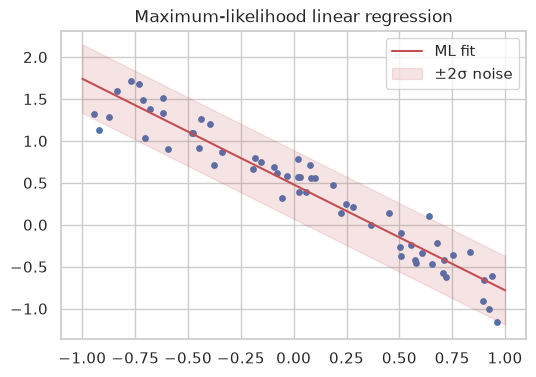

In [2]:
rng = np.random.default_rng(1)
N = 60
x = rng.uniform(-1, 1, N)
t = 0.5 - 1.3 * x + rng.normal(0, 0.25, N)           # true w=(0.5,-1.3), noise sd 0.25
Phi = np.c_[np.ones(N), x]

w_ml = np.linalg.solve(Phi.T @ Phi, Phi.T @ t)       # normal equations
sigma2_ml = np.mean((t - Phi @ w_ml) ** 2)

def nll(p):                                           # p = (w0, w1, log beta)
    w, beta = p[:2], np.exp(p[2])
    r = t - Phi @ w
    return -(0.5 * N * np.log(beta) - 0.5 * N * np.log(2 * np.pi) - 0.5 * beta * r @ r)

res = optimize.minimize(nll, x0=[0, 0, 0])
print("closed form  w_ML =", w_ml.round(4), " sigma^2_ML =", round(sigma2_ml, 4))
print("numerical ML  w   =", res.x[:2].round(4), " sigma^2    =", round(1 / np.exp(res.x[2]), 4))

xs = np.linspace(-1, 1, 100)
plt.figure(figsize=(6, 4)); plt.scatter(x, t, s=15)
plt.plot(xs, w_ml[0] + w_ml[1] * xs, "r", label="ML fit"); plt.fill_between(xs, w_ml[0] + w_ml[1]*xs - 2*np.sqrt(sigma2_ml), w_ml[0] + w_ml[1]*xs + 2*np.sqrt(sigma2_ml), alpha=.15, color="r", label="±2σ noise")
plt.legend(); plt.title("Maximum-likelihood linear regression"); plt.show()

### A2. Robust linear regression
Squared error gives outliers a huge pull. The **Huber loss** is quadratic for small residuals and linear for large ones
(equivalently, heavy-tailed noise). **RANSAC** fits on consensus inliers only.

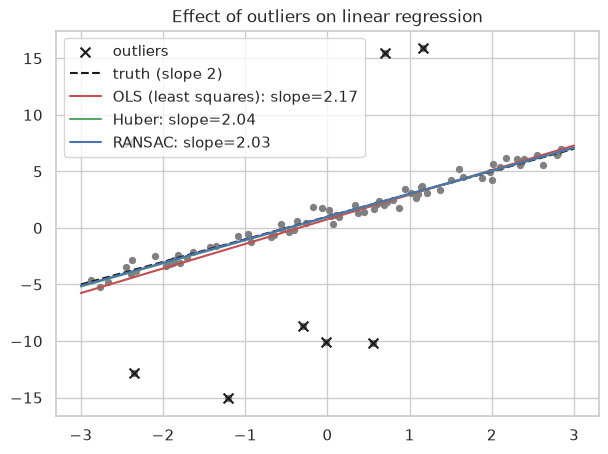

In [3]:
rng = np.random.default_rng(2)
x = rng.uniform(-3, 3, 80); t = 1 + 2 * x + rng.normal(0, 0.5, 80)
out = rng.choice(80, 8, replace=False); t[out] += rng.choice([-1, 1], 8) * rng.uniform(8, 14, 8)   # gross outliers
X = x[:, None]; xs = np.linspace(-3, 3, 100)[:, None]

models = {"OLS (least squares)": LinearRegression(), "Huber": HuberRegressor(), "RANSAC": RANSACRegressor(random_state=0)}
plt.figure(figsize=(7, 5)); plt.scatter(x, t, s=18, c="gray"); plt.scatter(x[out], t[out], c="k", marker="x", s=50, label="outliers")
plt.plot(xs, 1 + 2 * xs, "k--", label="truth (slope 2)")
for (name, m), c in zip(models.items(), ["r", "g", "b"]):
    m.fit(X, t)
    coef = m.estimator_.coef_[0] if hasattr(m, "estimator_") else m.coef_[0]
    plt.plot(xs, m.predict(xs), c, label=f"{name}: slope={coef:.2f}")
plt.legend(); plt.title("Effect of outliers on linear regression"); plt.show()

### A3. Ridge regression (L2-regularised least squares)
$\mathbf w_{ridge}=(\lambda I+\Phi^\top\Phi)^{-1}\Phi^\top\mathbf t$. This is the MAP estimate under a zero-mean Gaussian prior on $\mathbf w$.
The coefficient path on the diabetes data shows weights shrinking as $\lambda$ grows.

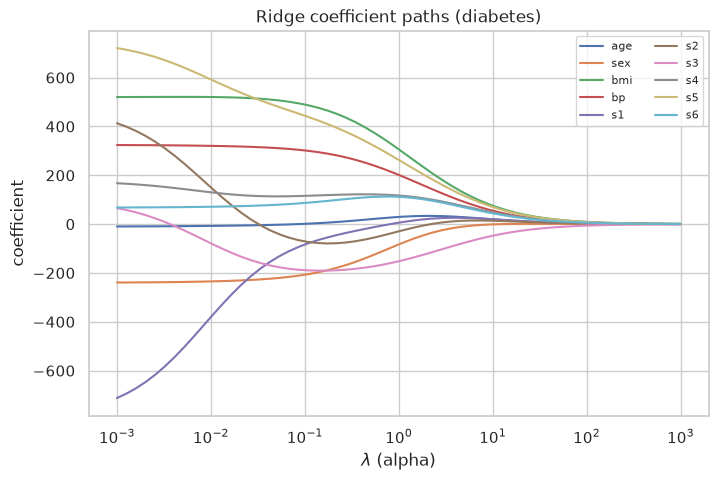

RidgeCV best alpha = 0.068   test R² = 0.365   (OLS test R² = 0.359)


In [4]:
diab = load_diabetes(as_frame=True)
Xd, yd = diab.data, diab.target
alphas = np.logspace(-3, 3, 60)
coefs = [Ridge(alpha=a).fit(Xd, yd).coef_ for a in alphas]

plt.figure(figsize=(8, 5))
for j, c in enumerate(np.array(coefs).T): plt.plot(alphas, c, label=Xd.columns[j])
plt.xscale("log"); plt.xlabel(r"$\lambda$ (alpha)"); plt.ylabel("coefficient"); plt.title("Ridge coefficient paths (diabetes)")
plt.legend(ncol=2, fontsize=8); plt.show()

Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.25, random_state=0)
cv = RidgeCV(alphas=alphas, cv=5).fit(Xtr, ytr)
print(f"RidgeCV best alpha = {cv.alpha_:.3f}   test R² = {cv.score(Xte, yte):.3f}   (OLS test R² = {LinearRegression().fit(Xtr, ytr).score(Xte, yte):.3f})")

### A4. Bayesian linear regression
With prior $p(\mathbf w)=\mathcal N(\mathbf 0,\alpha^{-1}I)$ and likelihood noise precision $\beta$ the posterior is Gaussian:

$$\mathbf S_N^{-1}=\alpha I+\beta\Phi^\top\Phi,\qquad \mathbf m_N=\beta\,\mathbf S_N\Phi^\top\mathbf t,$$

and the predictive distribution is $\mathcal N\big(\mathbf m_N^\top\phi(x),\ \beta^{-1}+\phi(x)^\top\mathbf S_N\phi(x)\big)$:
it reports **how uncertain** the model is. Below the posterior is updated as data arrive (Bishop Fig. 3.8) with Gaussian basis functions.

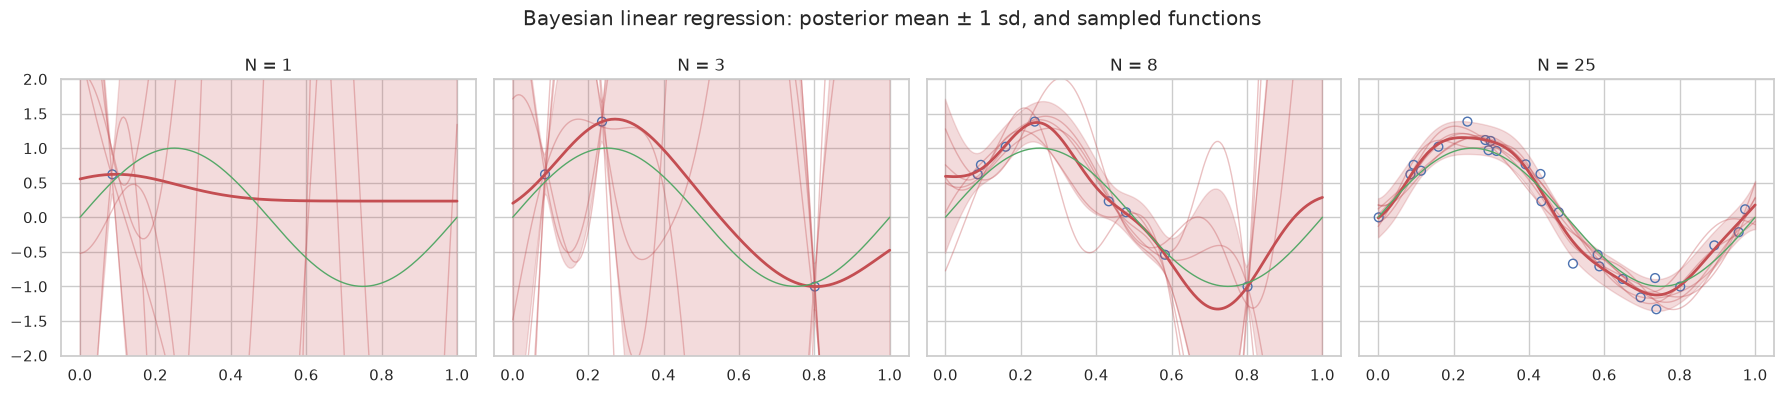

In [5]:
def gauss_basis(x, centers=np.linspace(0, 1, 9), s=0.12):
    x = np.atleast_1d(x)[:, None]
    return np.c_[np.ones(len(x)), np.exp(-(x - centers[None]) ** 2 / (2 * s ** 2))]

def posterior(Phi, t, alpha, beta):
    S_inv = alpha * np.eye(Phi.shape[1]) + beta * Phi.T @ Phi
    S = np.linalg.inv(S_inv)
    return beta * S @ Phi.T @ t, S

alpha, beta = 1e-2, 1 / 0.2 ** 2
rng = np.random.default_rng(3)
xa = rng.uniform(0, 1, 25); ta = np.sin(2 * np.pi * xa) + rng.normal(0, 0.2, 25)
xg = np.linspace(0, 1, 200); Pg = gauss_basis(xg)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, k in zip(axes, [1, 3, 8, 25]):
    m, S = posterior(gauss_basis(xa[:k]), ta[:k], alpha, beta)
    mean = Pg @ m; sd = np.sqrt(1 / beta + np.einsum("ij,jk,ik->i", Pg, S, Pg))
    for w in rng.multivariate_normal(m, S, 6): ax.plot(xg, Pg @ w, c="r", alpha=0.35, lw=1)
    ax.plot(xg, mean, "r", lw=2); ax.fill_between(xg, mean - sd, mean + sd, color="r", alpha=0.2)
    ax.plot(xg, np.sin(2 * np.pi * xg), "g", lw=1); ax.scatter(xa[:k], ta[:k], facecolors="none", edgecolors="b", s=40)
    ax.set_title(f"N = {k}"); ax.set_ylim(-2, 2)
plt.suptitle("Bayesian linear regression: posterior mean ± 1 sd, and sampled functions"); plt.tight_layout(); plt.show()

## Practice 1 — Linear regression for prediction
**Problem:** predict disease progression one year after baseline from 10 physiological variables (diabetes data, 442 patients).
Steps: explore → split → fit from scratch (normal equations) → compare with scikit-learn → evaluate (MSE, RMSE, MAE, R²) → diagnose residuals → cross-validate → interpret.

(442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


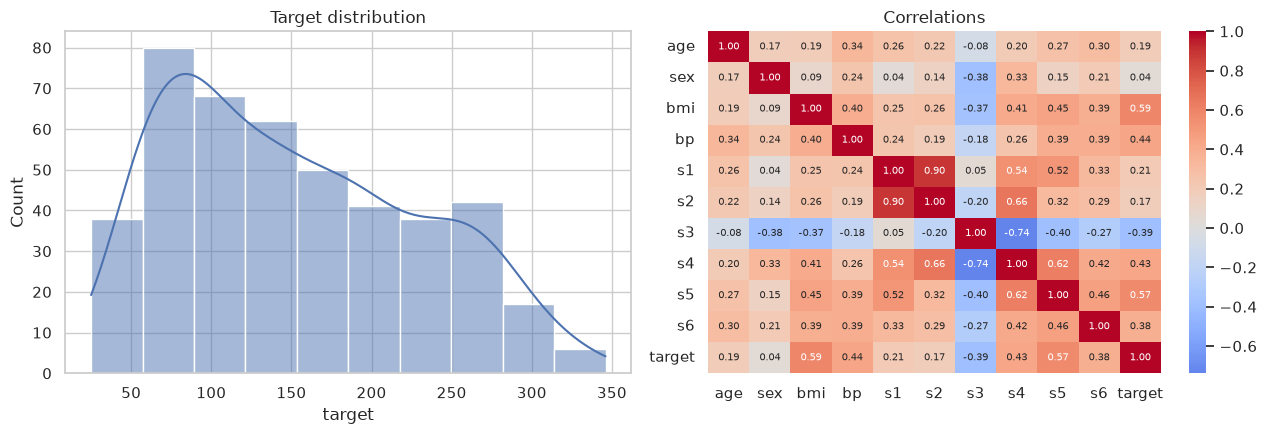

In [6]:
df = diab.frame
print(df.shape); display(df.head())
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["target"], kde=True, ax=ax[0]); ax[0].set_title("Target distribution")
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax[1]); ax[1].set_title("Correlations")
plt.tight_layout(); plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(Xd, yd, test_size=0.2, random_state=42)

# --- From scratch: w = (X^T X)^-1 X^T y  (with bias column) ---
class MyLinearRegression:
    def fit(self, X, y):
        A = np.c_[np.ones(len(X)), np.asarray(X)]
        self.w_ = np.linalg.pinv(A) @ np.asarray(y)          # numerically stable least squares
        return self
    def predict(self, X): return np.c_[np.ones(len(X)), np.asarray(X)] @ self.w_

mine = MyLinearRegression().fit(X_train, y_train)
sk = LinearRegression().fit(X_train, y_train)
print("max |coef difference| scratch vs sklearn:", np.abs(mine.w_[1:] - sk.coef_).max().round(10))
print("intercepts:", mine.w_[0].round(4), sk.intercept_.round(4))

def report(name, y_true, y_pred):
    return {"model": name, "MSE": mean_squared_error(y_true, y_pred), "RMSE": mean_squared_error(y_true, y_pred) ** .5,
            "MAE": mean_absolute_error(y_true, y_pred), "R2": r2_score(y_true, y_pred)}

baseline = np.full(len(y_test), y_train.mean())
res = pd.DataFrame([report("mean baseline", y_test, baseline),
                    report("linear (scratch) – test", y_test, mine.predict(X_test)),
                    report("linear (sklearn) – train", y_train, sk.predict(X_train)),
                    report("linear (sklearn) – test", y_test, sk.predict(X_test))]).set_index("model").round(3)
display(res)

max |coef difference| scratch vs sklearn: 0.0
intercepts: 151.3456 151.3456


,MSE,RMSE,MAE,R2
model,,,,
mean baseline,5361.533,73.222,64.006,-0.012
linear (scratch) – test,2900.194,53.853,42.794,0.453
linear (sklearn) – train,2868.550,53.559,43.484,0.528
linear (sklearn) – test,2900.194,53.853,42.794,0.453


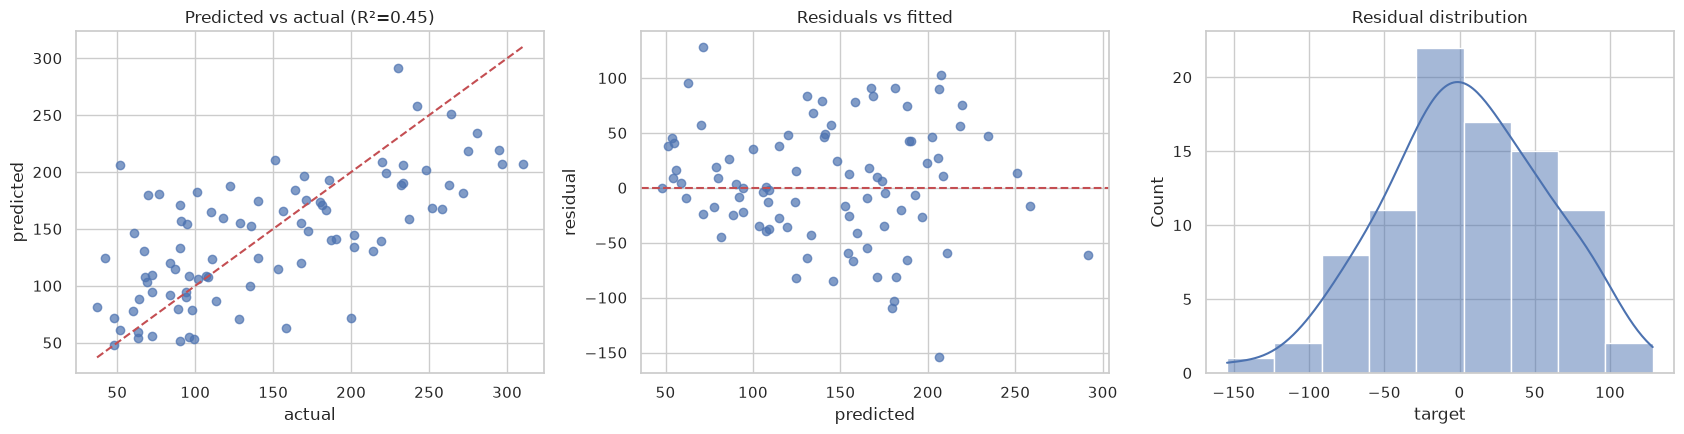

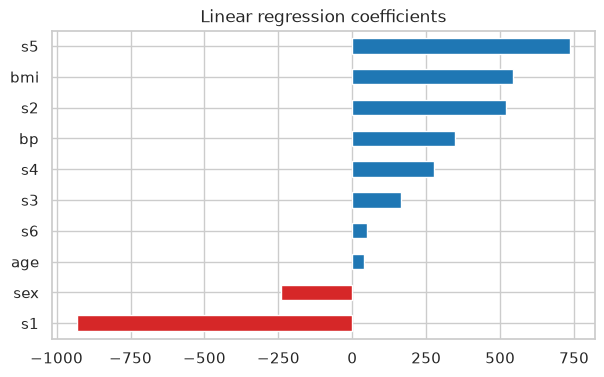

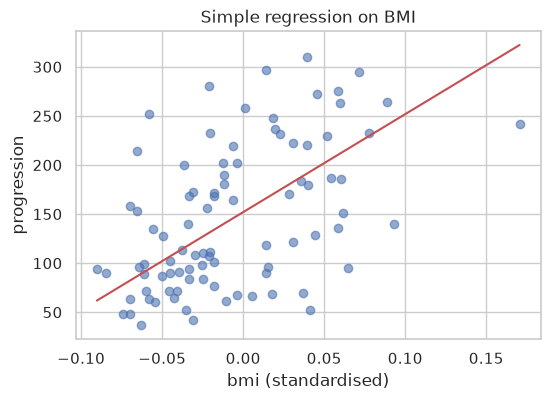

In [8]:
pred = sk.predict(X_test); resid = y_test - pred
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].scatter(y_test, pred, alpha=.7); lim = [y_test.min(), y_test.max()]; ax[0].plot(lim, lim, "r--")
ax[0].set(xlabel="actual", ylabel="predicted", title=f"Predicted vs actual (R²={r2_score(y_test, pred):.2f})")
ax[1].scatter(pred, resid, alpha=.7); ax[1].axhline(0, c="r", ls="--"); ax[1].set(xlabel="predicted", ylabel="residual", title="Residuals vs fitted")
sns.histplot(resid, kde=True, ax=ax[2]); ax[2].set_title("Residual distribution")
plt.tight_layout(); plt.show()

# coefficient interpretation
coef = pd.Series(sk.coef_, index=Xd.columns).sort_values()
plt.figure(figsize=(7, 4)); coef.plot.barh(color=np.where(coef > 0, "tab:blue", "tab:red")); plt.title("Linear regression coefficients"); plt.show()

# single-feature view: BMI only
b = LinearRegression().fit(X_train[["bmi"]], y_train); g = np.linspace(Xd.bmi.min(), Xd.bmi.max(), 50)[:, None]
plt.figure(figsize=(6, 4)); plt.scatter(X_test["bmi"], y_test, alpha=.6); plt.plot(g, b.predict(pd.DataFrame(g, columns=["bmi"])), "r")
plt.xlabel("bmi (standardised)"); plt.ylabel("progression"); plt.title("Simple regression on BMI"); plt.show()

5-fold CV R²: [0.43  0.523 0.483 0.426 0.55 ]  mean = 0.482 ± 0.049


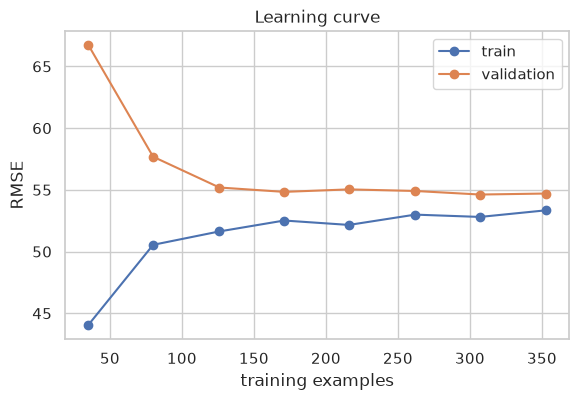

OLS deg-2    CV R² = 0.392
Ridge deg-2  CV R² = 0.470


In [9]:
# 5-fold cross-validation and learning curve
cvs = cross_val_score(LinearRegression(), Xd, yd, cv=5, scoring="r2")
print("5-fold CV R²:", cvs.round(3), " mean = %.3f ± %.3f" % (cvs.mean(), cvs.std()))

sizes, trs, vas = learning_curve(LinearRegression(), Xd, yd, cv=5, scoring="neg_root_mean_squared_error",
                                 train_sizes=np.linspace(0.1, 1, 8), random_state=0, shuffle=True)
plt.figure(figsize=(6.5, 4)); plt.plot(sizes, -trs.mean(1), "o-", label="train"); plt.plot(sizes, -vas.mean(1), "o-", label="validation")
plt.xlabel("training examples"); plt.ylabel("RMSE"); plt.legend(); plt.title("Learning curve"); plt.show()

# ridge vs OLS with CV on polynomial features (regularisation helps when the model is flexible)
from sklearn.preprocessing import PolynomialFeatures
for name, mdl in [("OLS deg-2", make_pipeline(PolynomialFeatures(2), StandardScaler(), LinearRegression())),
                  ("Ridge deg-2", make_pipeline(PolynomialFeatures(2), StandardScaler(), Ridge(alpha=100)))]:
    print(f"{name:<12} CV R² = {cross_val_score(mdl, Xd, yd, cv=5, scoring='r2').mean():.3f}")

### A5. Linear models for classification: generative vs. discriminative
* **Discriminant function** – directly map $\mathbf x\to$ class (e.g. perceptron, Fisher LDA).
* **Probabilistic generative** – model $p(\mathbf x|C_k)p(C_k)$ then use Bayes (Gaussian class-conditionals with shared covariance ⇒ LDA, a *linear* boundary).
* **Probabilistic discriminative** – model $p(C_k|\mathbf x)$ directly: **logistic regression** $p(C_1|\mathbf x)=\sigma(\mathbf w^\top\phi)$.

Both families give a linear decision boundary here; the generative route needs stronger assumptions but can work with less data.

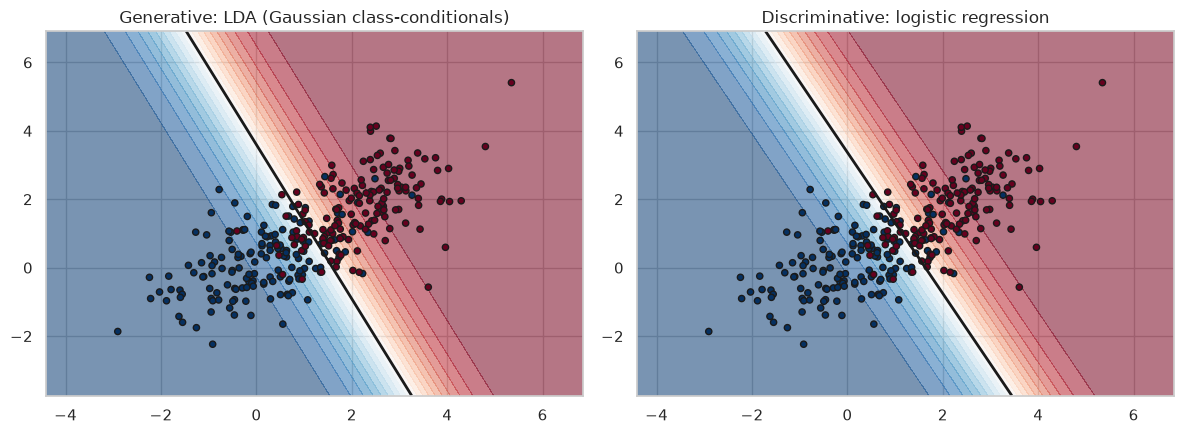

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
rng = np.random.default_rng(0)
S = np.array([[1.0, 0.5], [0.5, 1.0]])
Xg = np.r_[rng.multivariate_normal([0, 0], S, 150), rng.multivariate_normal([2.2, 1.8], S, 150)]; yg = np.r_[np.zeros(150), np.ones(150)]

def boundary(ax, model, X, y, title, pad=1.5, levels=(0.5,), fill=True, proba=True):
    g0, g1 = np.meshgrid(np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 300), np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 300))
    G = np.c_[g0.ravel(), g1.ravel()]
    Z = model.predict_proba(G)[:, 1] if proba else model.decision_function(G)
    if fill: ax.contourf(g0, g1, Z.reshape(g0.shape), levels=20, cmap="RdBu_r", alpha=.55, vmin=0 if proba else None, vmax=1 if proba else None)
    ax.contour(g0, g1, Z.reshape(g0.shape), levels=list(levels), colors="k", linewidths=2)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu_r", edgecolor="k", s=20); ax.set_title(title)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
boundary(ax[0], LinearDiscriminantAnalysis().fit(Xg, yg), Xg, yg, "Generative: LDA (Gaussian class-conditionals)")
boundary(ax[1], LogisticRegression().fit(Xg, yg), Xg, yg, "Discriminative: logistic regression")
plt.tight_layout(); plt.show()

### A6. Laplace approximation
To approximate an intractable posterior with a Gaussian, find its mode $\mathbf z_0$ and match the curvature:
$q(\mathbf z)=\mathcal N(\mathbf z_0,\mathbf A^{-1})$, $\mathbf A=-\nabla\nabla\ln p(\mathbf z)|_{\mathbf z_0}$.
Example: $p(z)\propto\exp(-z^2/2)\,\sigma(20z+4)$ (Bishop Fig. 4.14).

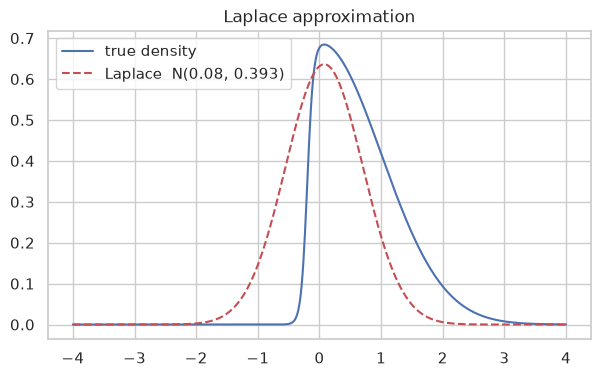

In [11]:
zs = np.linspace(-4, 4, 600)
logp = lambda z: -z ** 2 / 2 + np.log(special.expit(20 * z + 4))
p = np.exp(logp(zs)); p /= np.trapezoid(p, zs)
z0 = optimize.minimize_scalar(lambda z: -logp(z)).x
h = 1e-4; A = -(logp(z0 + h) - 2 * logp(z0) + logp(z0 - h)) / h ** 2          # numerical -d²/dz² ln p
q = np.exp(-A * (zs - z0) ** 2 / 2); q /= np.trapezoid(q, zs)
plt.figure(figsize=(7, 4)); plt.plot(zs, p, label="true density"); plt.plot(zs, q, "r--", label=f"Laplace  N({z0:.2f}, {1/A:.3f})")
plt.legend(); plt.title("Laplace approximation"); plt.show()

## Practice 2 — Bayesian logistic regression and SVM for classification

### 2a. Bayesian logistic regression (Laplace approximation, implemented from scratch)
Model: $p(t=1|\phi,\mathbf w)=\sigma(\mathbf w^\top\phi)$, prior $\mathbf w\sim\mathcal N(\mathbf 0,\alpha^{-1}I)$.
1. Find $\mathbf w_{MAP}$ by Newton–Raphson (IRLS): $\mathbf w\leftarrow\mathbf w-\mathbf H^{-1}\nabla$, with $\nabla=\Phi^\top(\mathbf y-\mathbf t)+\alpha\mathbf w$, $\mathbf H=\Phi^\top R\Phi+\alpha I$, $R=\mathrm{diag}(y_n(1-y_n))$.
2. Posterior $\approx\mathcal N(\mathbf w_{MAP},\mathbf S_N)$, $\mathbf S_N=\mathbf H^{-1}$.
3. Predictive (probit approximation): $p(t=1|\phi)\approx\sigma\!\big(\kappa(\sigma_a^2)\mu_a\big)$, $\mu_a=\mathbf w_{MAP}^\top\phi$, $\sigma_a^2=\phi^\top\mathbf S_N\phi$, $\kappa=(1+\pi\sigma_a^2/8)^{-1/2}$.

The Bayesian predictive is **less over-confident** away from the data than the MAP plug-in estimate.

In [12]:
class BayesianLogisticRegression:
    """Binary Bayesian logistic regression with a Gaussian prior and Laplace approximation."""
    def __init__(self, alpha=1.0, max_iter=50, tol=1e-8):
        self.alpha, self.max_iter, self.tol = alpha, max_iter, tol

    @staticmethod
    def _design(X): return np.c_[np.ones(len(X)), np.asarray(X, float)]

    def fit(self, X, t):
        Phi, t = self._design(X), np.asarray(t, float)
        w = np.zeros(Phi.shape[1])
        for _ in range(self.max_iter):
            y = special.expit(Phi @ w)
            grad = Phi.T @ (y - t) + self.alpha * w
            H = (Phi * (y * (1 - y))[:, None]).T @ Phi + self.alpha * np.eye(len(w))
            step = np.linalg.solve(H, grad); w = w - step
            if np.linalg.norm(step) < self.tol: break
        self.w_map_ = w
        y = special.expit(Phi @ w)
        self.S_ = np.linalg.inv((Phi * (y * (1 - y))[:, None]).T @ Phi + self.alpha * np.eye(len(w)))
        self.classes_ = np.array([0, 1])
        return self

    def _activation(self, X):
        Phi = self._design(X)
        mu = Phi @ self.w_map_
        var = np.einsum("ij,jk,ik->i", Phi, self.S_, Phi)
        return mu, var

    def predict_proba_map(self, X):
        mu, _ = self._activation(X); p = special.expit(mu); return np.c_[1 - p, p]

    def predict_proba(self, X):
        mu, var = self._activation(X)
        p = special.expit(mu / np.sqrt(1 + np.pi * var / 8)); return np.c_[1 - p, p]

    def predict(self, X): return (self.predict_proba(X)[:, 1] > 0.5).astype(int)

    def sample_weights(self, n, seed=0):
        return np.random.default_rng(seed).multivariate_normal(self.w_map_, self.S_, n)

# sanity check: with a very weak prior it should match unregularised sklearn logistic regression
Xs, ys = make_moons(300, noise=0.25, random_state=1)
blr_check = BayesianLogisticRegression(alpha=1e-6).fit(Xs, ys)
sk_check = LogisticRegression(C=1e8, max_iter=1000).fit(Xs, ys)
print("w_MAP (ours)   :", blr_check.w_map_.round(3))
print("w (sklearn)    :", np.r_[sk_check.intercept_, sk_check.coef_[0]].round(3))

w_MAP (ours)   : [ 0.363  1.325 -4.101]
w (sklearn)    : [ 0.363  1.325 -4.102]


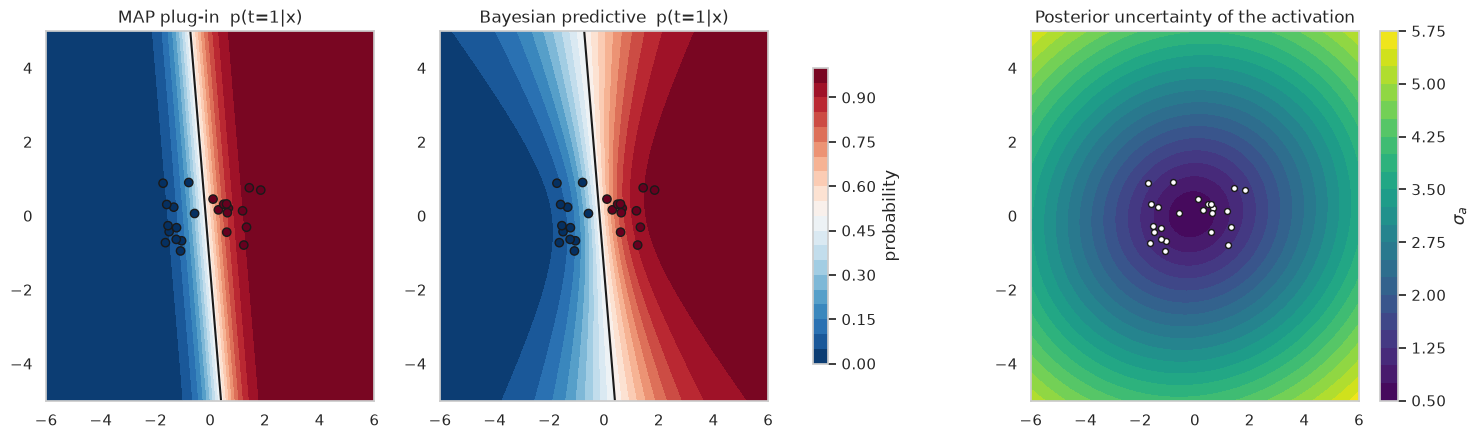

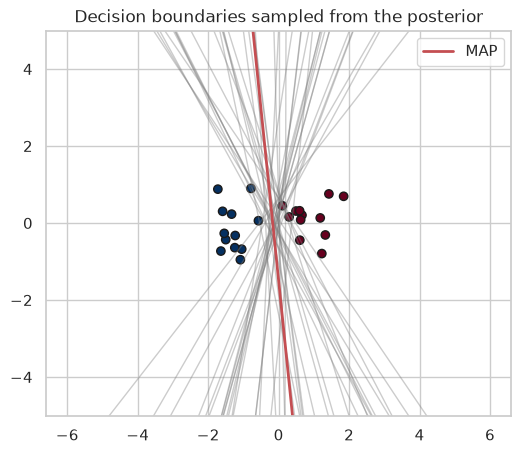

In [13]:
# Small data set: where the Bayesian treatment matters. Use 2-D data with a few points on the left.
rng = np.random.default_rng(5)
Xb = np.r_[rng.normal([-1.2, 0], .55, (12, 2)), rng.normal([1.2, 0.3], .55, (12, 2))]; yb = np.r_[np.zeros(12), np.ones(12)]
blr = BayesianLogisticRegression(alpha=1.0).fit(Xb, yb)

g0, g1 = np.meshgrid(np.linspace(-6, 6, 300), np.linspace(-5, 5, 300)); G = np.c_[g0.ravel(), g1.ravel()]
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
for a, P, title in [(ax[0], blr.predict_proba_map(G)[:, 1], "MAP plug-in  p(t=1|x)"), (ax[1], blr.predict_proba(G)[:, 1], "Bayesian predictive  p(t=1|x)")]:
    c = a.contourf(g0, g1, P.reshape(g0.shape), levels=20, cmap="RdBu_r", vmin=0, vmax=1)
    a.contour(g0, g1, P.reshape(g0.shape), levels=[.5], colors="k"); a.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="RdBu_r", edgecolor="k"); a.set_title(title)
plt.colorbar(c, ax=ax[:2], shrink=.8, label="probability")
_, var = blr._activation(G)
c = ax[2].contourf(g0, g1, np.sqrt(var).reshape(g0.shape), levels=20, cmap="viridis"); plt.colorbar(c, ax=ax[2], label=r"$\sigma_a$")
ax[2].scatter(Xb[:, 0], Xb[:, 1], c="w", edgecolor="k", s=18); ax[2].set_title("Posterior uncertainty of the activation")
plt.show()

# samples from the weight posterior = a distribution of linear boundaries
plt.figure(figsize=(6, 5)); xs = np.linspace(-6, 6, 50)
for w in blr.sample_weights(40):
    plt.plot(xs, -(w[0] + w[1] * xs) / w[2], c="gray", alpha=.4, lw=1)
w = blr.w_map_; plt.plot(xs, -(w[0] + w[1] * xs) / w[2], "r", lw=2, label="MAP")
plt.scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="RdBu_r", edgecolor="k"); plt.ylim(-5, 5); plt.legend(); plt.title("Decision boundaries sampled from the posterior"); plt.show()

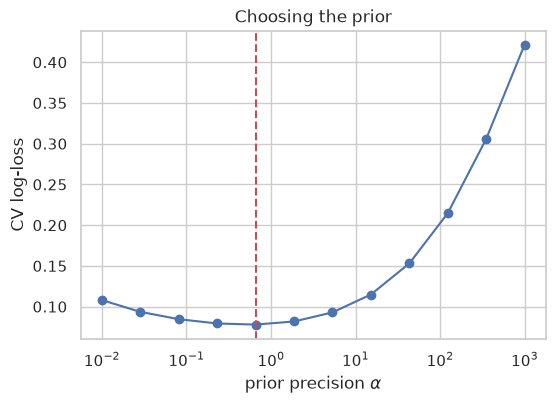

best alpha = 0.658
Bayesian : acc=0.958  AUC=0.994  log-loss=0.098
MAP only : acc=0.958  AUC=0.995  log-loss=0.085


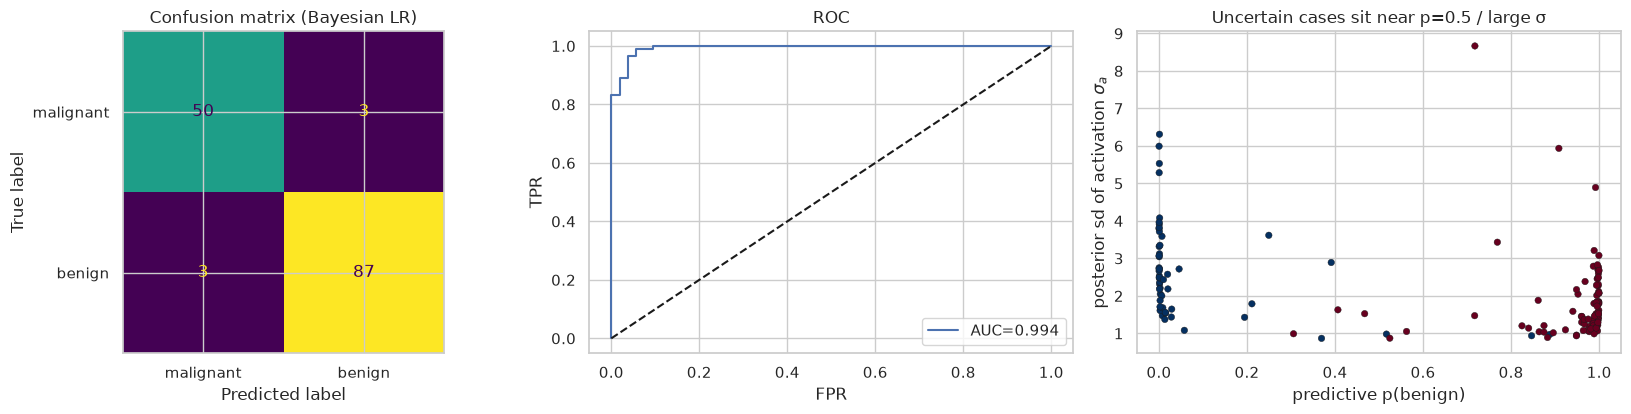

In [14]:
# Real data: breast-cancer (569 samples, 30 features). Choose the prior precision alpha by cross-validated log-loss.
bc = load_breast_cancer(as_frame=True)
Xtr, Xte, ytr, yte = train_test_split(bc.data, bc.target, test_size=0.25, stratify=bc.target, random_state=0)
sc = StandardScaler().fit(Xtr); Ztr, Zte = sc.transform(Xtr), sc.transform(Xte)

from sklearn.model_selection import StratifiedKFold
alphas = np.logspace(-2, 3, 12); skf = StratifiedKFold(5, shuffle=True, random_state=0); cvll = []
for a in alphas:
    ll = []
    for tr_i, va_i in skf.split(Ztr, ytr):
        m = BayesianLogisticRegression(alpha=a).fit(Ztr[tr_i], ytr.iloc[tr_i]); ll.append(log_loss(ytr.iloc[va_i], m.predict_proba(Ztr[va_i])))
    cvll.append(np.mean(ll))
best_alpha = alphas[int(np.argmin(cvll))]
plt.figure(figsize=(6, 4)); plt.semilogx(alphas, cvll, "o-"); plt.axvline(best_alpha, c="r", ls="--"); plt.xlabel(r"prior precision $\alpha$"); plt.ylabel("CV log-loss"); plt.title("Choosing the prior"); plt.show()

bayes = BayesianLogisticRegression(alpha=best_alpha).fit(Ztr, ytr)
pb, pm = bayes.predict_proba(Zte)[:, 1], bayes.predict_proba_map(Zte)[:, 1]
print(f"best alpha = {best_alpha:.3g}")
print(f"Bayesian : acc={accuracy_score(yte, pb > .5):.3f}  AUC={roc_auc_score(yte, pb):.3f}  log-loss={log_loss(yte, pb):.3f}")
print(f"MAP only : acc={accuracy_score(yte, pm > .5):.3f}  AUC={roc_auc_score(yte, pm):.3f}  log-loss={log_loss(yte, pm):.3f}")

mu, var = bayes._activation(Zte)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))
ConfusionMatrixDisplay(confusion_matrix(yte, pb > .5), display_labels=bc.target_names).plot(ax=ax[0], colorbar=False); ax[0].set_title("Confusion matrix (Bayesian LR)")
fpr, tpr, _ = roc_curve(yte, pb); ax[1].plot(fpr, tpr, label=f"AUC={roc_auc_score(yte, pb):.3f}"); ax[1].plot([0, 1], [0, 1], "k--"); ax[1].set(xlabel="FPR", ylabel="TPR", title="ROC"); ax[1].legend()
ax[2].scatter(pb, np.sqrt(var), c=yte, cmap="RdBu_r", s=22, edgecolor="k", lw=.3); ax[2].set(xlabel="predictive p(benign)", ylabel=r"posterior sd of activation $\sigma_a$", title="Uncertain cases sit near p=0.5 / large σ")
plt.tight_layout(); plt.show()

### 2b. Kernels, the kernel trick and SVMs
A kernel $k(\mathbf x,\mathbf x')=\phi(\mathbf x)^\top\phi(\mathbf x')$ lets a linear model work in a high-dimensional feature space without computing $\phi$.
Common choices: linear, polynomial $(\gamma\mathbf x^\top\mathbf x'+r)^d$, RBF $\exp(-\gamma\|\mathbf x-\mathbf x'\|^2)$.
The SVM maximises the margin and uses only **support vectors**: $y(\mathbf x)=\sum_{n\in SV}a_nt_nk(\mathbf x,\mathbf x_n)+b$.

**Kernel-trick demo.** Concentric circles are not linearly separable in 2-D, but the explicit map $\phi(\mathbf x)=(x_1,x_2,x_1^2+x_2^2)$ makes them separable by a plane. The polynomial kernel $(\mathbf x^\top\mathbf x')^2$ computes the inner product of the map $(x_1^2,\sqrt2x_1x_2,x_2^2)$ implicitly.

linear-kernel SVM accuracy: 0.583    RBF-kernel SVM accuracy: 1.000


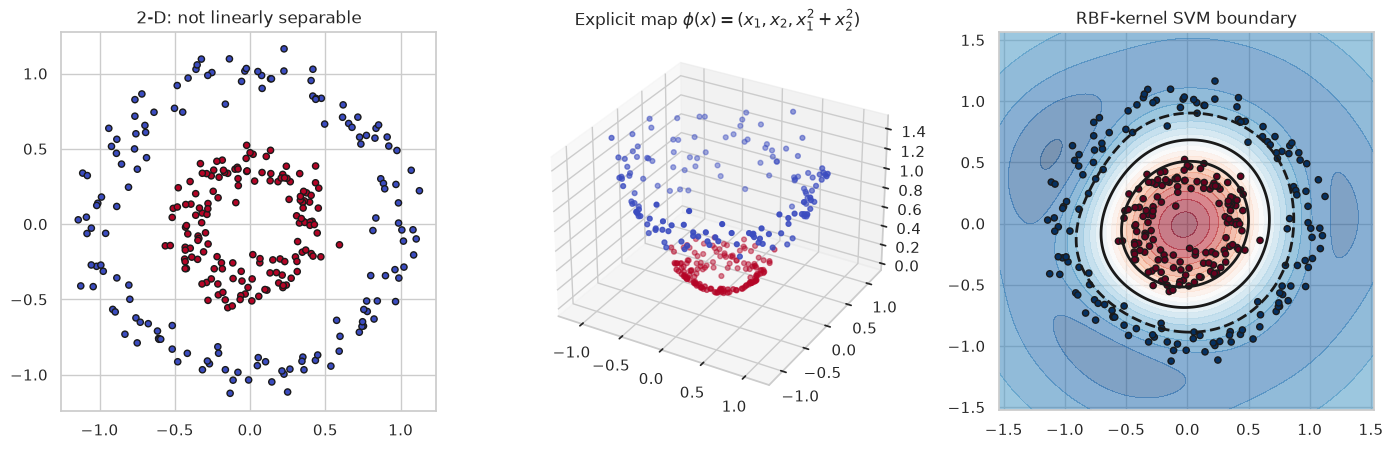

kernel (a.b)^2 = 0.00725042    explicit phi(a).phi(b) = 0.00725042


In [15]:
Xc, yc = make_circles(300, noise=0.08, factor=0.4, random_state=0)
fig = plt.figure(figsize=(14, 4.5))
ax = fig.add_subplot(1, 3, 1); ax.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k", s=20); ax.set_title("2-D: not linearly separable"); ax.set_aspect("equal")
ax = fig.add_subplot(1, 3, 2, projection="3d"); Z3 = Xc[:, 0] ** 2 + Xc[:, 1] ** 2
ax.scatter(Xc[:, 0], Xc[:, 1], Z3, c=yc, cmap="coolwarm", s=12); ax.set_title(r"Explicit map $\phi(x)=(x_1,x_2,x_1^2+x_2^2)$")
ax = fig.add_subplot(1, 3, 3)
lin = SVC(kernel="linear").fit(Xc, yc); rbf = SVC(kernel="rbf", gamma=2).fit(Xc, yc)
print(f"linear-kernel SVM accuracy: {lin.score(Xc, yc):.3f}    RBF-kernel SVM accuracy: {rbf.score(Xc, yc):.3f}")
boundary(ax, rbf, Xc, yc, "RBF-kernel SVM boundary", pad=.4, levels=(-1, 0, 1), proba=False); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

# verify (x.x')^2 == phi(x).phi(x')
a, b = Xc[0], Xc[1]; phi = lambda v: np.array([v[0] ** 2, np.sqrt(2) * v[0] * v[1], v[1] ** 2])
print("kernel (a.b)^2 =", round((a @ b) ** 2, 8), "   explicit phi(a).phi(b) =", round(phi(a) @ phi(b), 8))

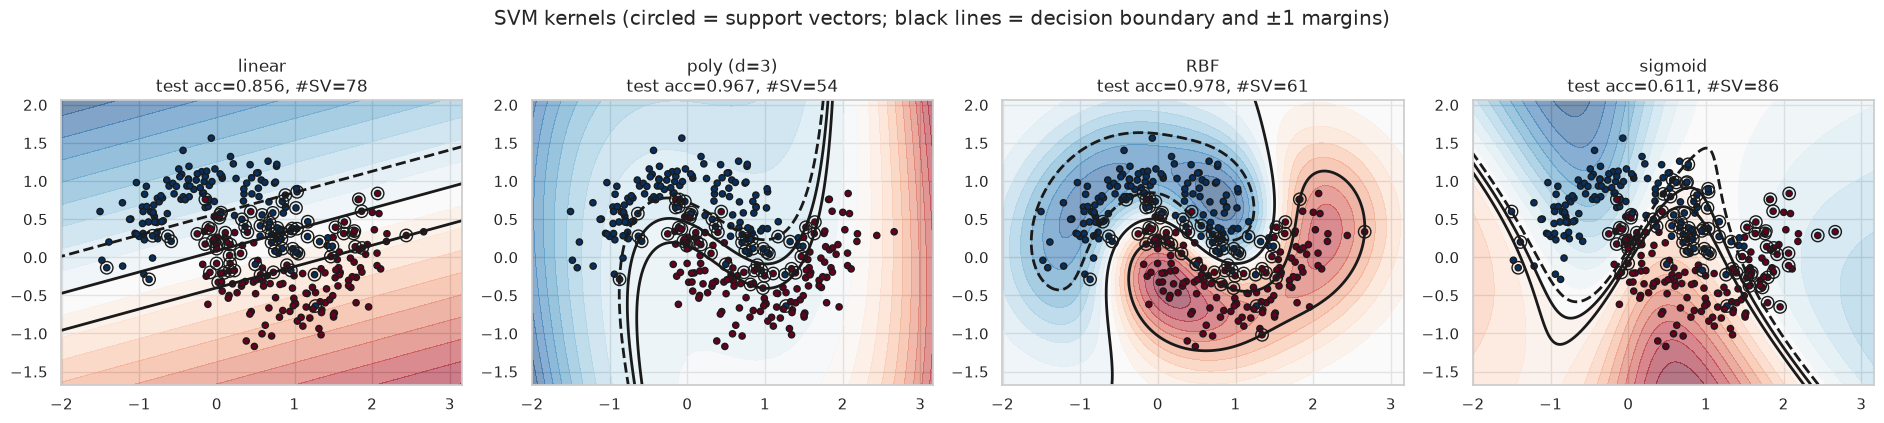

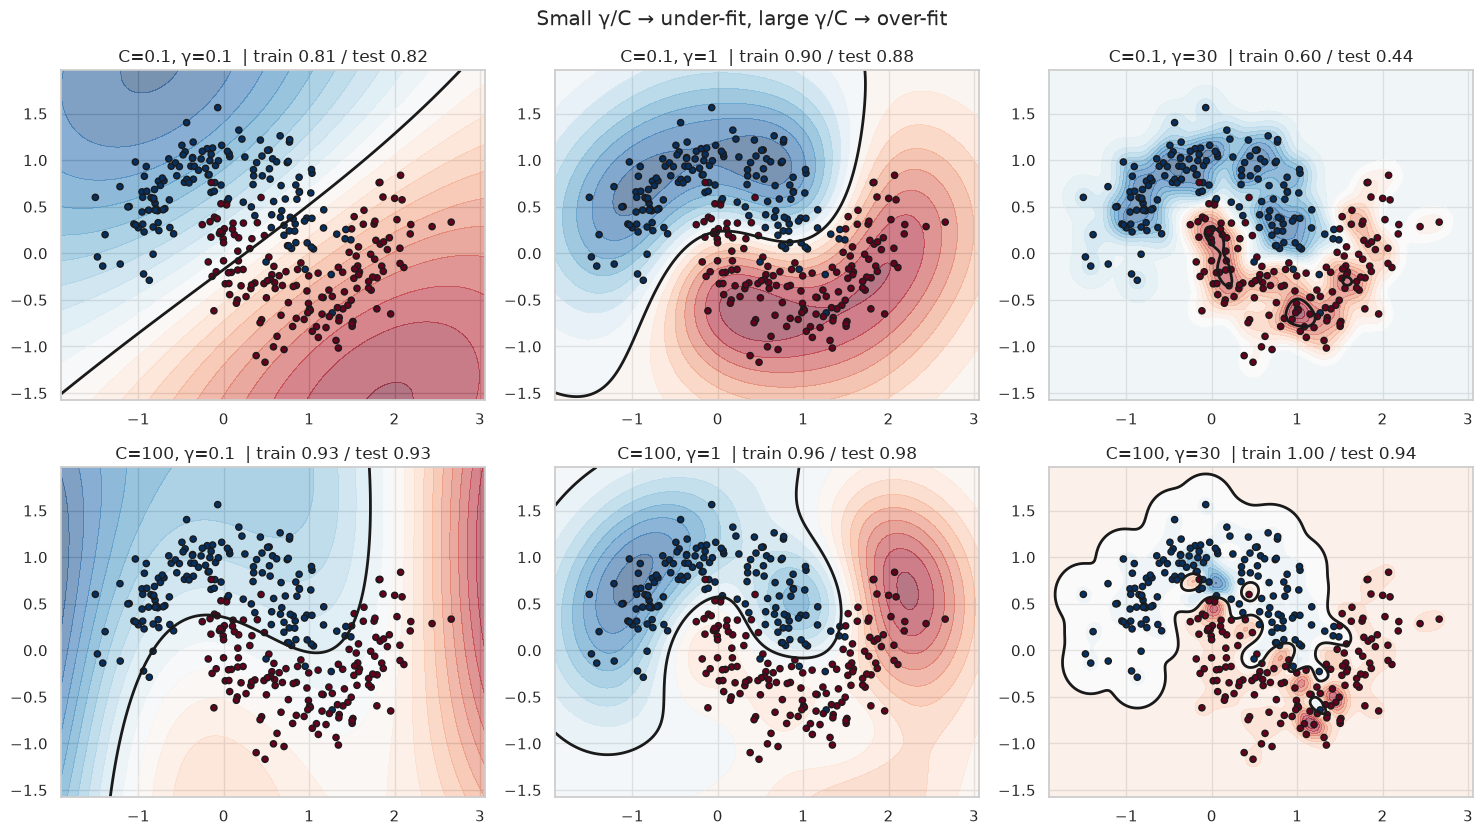

In [16]:
# Effect of the kernel on a non-linear problem (moons)
Xm, ym = make_moons(300, noise=0.25, random_state=0)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=0)
kernels = {"linear": SVC(kernel="linear"), "poly (d=3)": SVC(kernel="poly", degree=3, coef0=1), "RBF": SVC(kernel="rbf", gamma=1.0), "sigmoid": SVC(kernel="sigmoid")}
fig, ax = plt.subplots(1, 4, figsize=(19, 4.3))
for a, (name, m) in zip(ax, kernels.items()):
    m.fit(Xm_tr, ym_tr); boundary(a, m, Xm, ym, f"{name}\ntest acc={m.score(Xm_te, ym_te):.3f}, #SV={m.n_support_.sum()}", pad=.5, levels=(-1, 0, 1), proba=False)
    a.scatter(*m.support_vectors_.T, s=80, facecolors="none", edgecolors="k", lw=1)
plt.suptitle("SVM kernels (circled = support vectors; black lines = decision boundary and ±1 margins)"); plt.tight_layout(); plt.show()

# Effect of C and gamma
fig, ax = plt.subplots(2, 3, figsize=(15, 8.5))
for i, C in enumerate([0.1, 100]):
    for j, gam in enumerate([0.1, 1, 30]):
        m = SVC(kernel="rbf", C=C, gamma=gam).fit(Xm_tr, ym_tr)
        boundary(ax[i, j], m, Xm, ym, f"C={C}, γ={gam}  | train {m.score(Xm_tr, ym_tr):.2f} / test {m.score(Xm_te, ym_te):.2f}", pad=.4, levels=(0,), proba=False)
plt.suptitle("Small γ/C → under-fit, large γ/C → over-fit"); plt.tight_layout(); plt.show()

best params: {'svc__C': np.float64(100.0), 'svc__gamma': np.float64(0.001)}  CV acc = 0.988


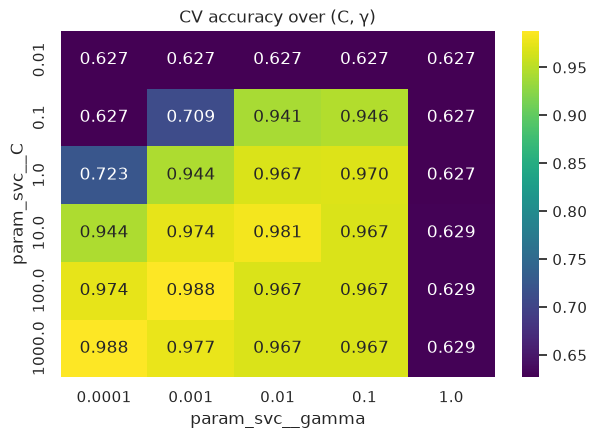

              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        53
      benign       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



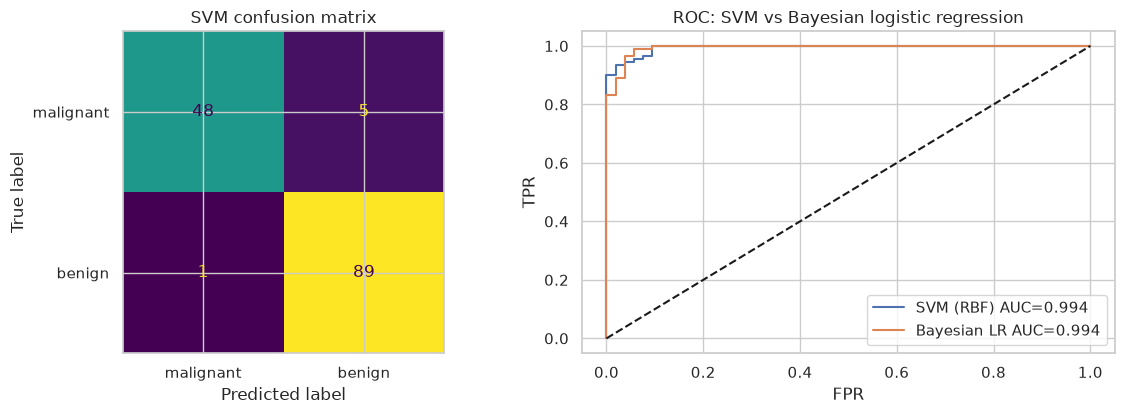

In [17]:
# SVM on the breast-cancer data: scaling + grid search over C and gamma (5-fold CV)
pipe = make_pipeline(StandardScaler(), SVC(kernel="rbf"))
grid = GridSearchCV(pipe, {"svc__C": np.logspace(-2, 3, 6), "svc__gamma": np.logspace(-4, 0, 5)}, cv=5, n_jobs=-1).fit(Xtr, ytr)
print("best params:", grid.best_params_, " CV acc = %.3f" % grid.best_score_)
sc_ = pd.DataFrame(grid.cv_results_)
heat = sc_.pivot_table(index="param_svc__C", columns="param_svc__gamma", values="mean_test_score")
plt.figure(figsize=(7, 4.5)); sns.heatmap(heat, annot=True, fmt=".3f", cmap="viridis"); plt.title("CV accuracy over (C, γ)"); plt.show()

best = make_pipeline(StandardScaler(), SVC(kernel="rbf", **{k.split("__")[1]: v for k, v in grid.best_params_.items()})).fit(Xtr, ytr)
pred = best.predict(Xte); ps = best.decision_function(Xte)      # signed distance to the margin; enough for a ROC curve
print(classification_report(yte, pred, target_names=bc.target_names))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ConfusionMatrixDisplay(confusion_matrix(yte, pred), display_labels=bc.target_names).plot(ax=ax[0], colorbar=False); ax[0].set_title("SVM confusion matrix")
for name, p in [("SVM (RBF)", ps), ("Bayesian LR", pb)]:
    f, t_, _ = roc_curve(yte, p); ax[1].plot(f, t_, label=f"{name} AUC={roc_auc_score(yte, p):.3f}")
ax[1].plot([0, 1], [0, 1], "k--"); ax[1].legend(); ax[1].set(xlabel="FPR", ylabel="TPR", title="ROC: SVM vs Bayesian logistic regression")
plt.tight_layout(); plt.show()

### Kernels inside a GLM
A kernel can also be used in a generalised linear model such as logistic regression: map the data with an (approximate) RBF feature map and
fit logistic regression on it — a *kernelised* logistic regression with a non-linear boundary.

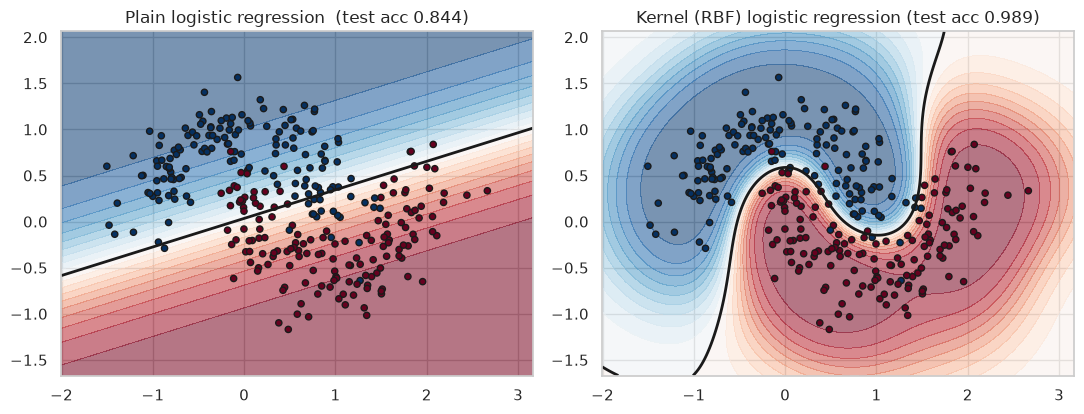

In [18]:
from sklearn.kernel_approximation import Nystroem
klr = make_pipeline(Nystroem(kernel="rbf", gamma=1.5, n_components=60, random_state=0), LogisticRegression(C=10, max_iter=2000)).fit(Xm_tr, ym_tr)
lr = LogisticRegression().fit(Xm_tr, ym_tr)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
boundary(ax[0], lr, Xm, ym, f"Plain logistic regression  (test acc {lr.score(Xm_te, ym_te):.3f})", pad=.5)
boundary(ax[1], klr, Xm, ym, f"Kernel (RBF) logistic regression (test acc {klr.score(Xm_te, ym_te):.3f})", pad=.5)
plt.tight_layout(); plt.show()

## Summary
* Least squares = maximum likelihood under Gaussian noise; Huber/RANSAC resist outliers; ridge = MAP with a Gaussian prior; Bayesian regression gives predictive uncertainty.
* Implemented linear regression from scratch and validated it against scikit-learn (R², RMSE, residual analysis, CV).
* Implemented Bayesian logistic regression with a Laplace approximation — it matches MAP accuracy on this data but additionally reports posterior uncertainty and is less over-confident far from the training data.
* Used kernels (kernel trick) and SVMs, tuned `C`/`γ`, and compared SVM with Bayesian logistic regression on real data.